In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

In [31]:
G1 = 600
# G2 = 1500

Rin = [1, 10, 100, 1000, 10000, 100000, 1000000] # Ohms
Gain_G2 = [1500, 1500, 1500, 1500, 1000, 400, 200]
Vsq_read = [0.5387, 0.5403, 0.5556, 0.6902, 0.9162, 0.8951, 0.4553] # ohms

/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_77852/679985649.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


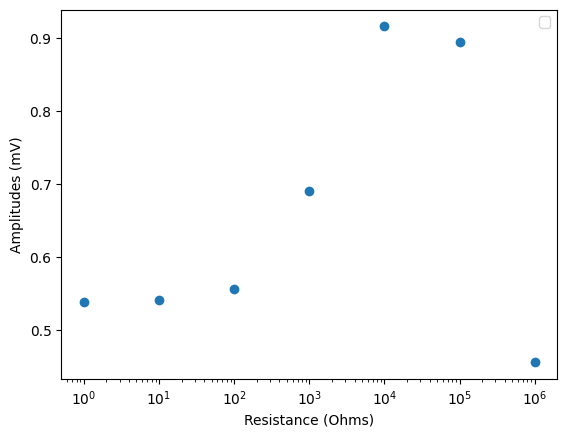

In [32]:
# Plot
plt.scatter(Rin, Vsq_read)
plt.xscale('log')
# plt.yrange(5,-5)
plt.xlabel('Resistance (Ohms)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel('Amplitudes (mV)')
# plt.title('Best Fit of Time Delay vs Cable Length')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [37]:
# Def 
def noise_quad(G2, Vsq):
    return Vsq * 10 / (G1 * G2)**2


noise_in_quad = []
for i in range(len(Vsq_read)):
    noise_in_quad.append(noise_quad(Gain_G2[i], Vsq_read[i]))
    print(noise_quad(Gain_G2[i], Vsq_read[i]))

6.650617283950617e-12
6.670370370370371e-12
6.8592592592592594e-12
8.520987654320988e-12
2.5450000000000003e-11
1.5539930555555557e-10
3.1618055555555557e-10


/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_77852/1002193765.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


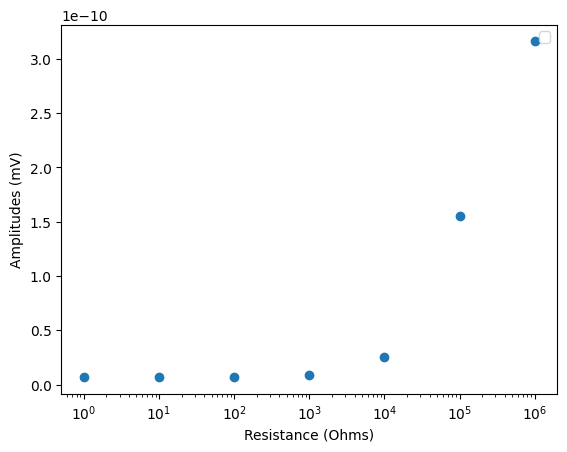

In [38]:
# Plot
plt.scatter(Rin[:], noise_in_quad[:])
plt.xscale('log')
# plt.yrange(5,-5)
plt.xlabel('Resistance (Ohms)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel('Amplitudes (mV)')
# plt.title('Best Fit of Time Delay vs Cable Length')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [35]:
# Fit to a linear function
# Plot using ODR
def linear_func(B, x):
    return B[0] * x + B[1]
linear = odr.Model(linear_func)

mydata = odr.RealData(Rin, noise_in_quad)

sol = odr.ODR(mydata, linear, beta0=[9., 1.])
myoutput = sol.run()
myoutput.pprint()

Beta: [2.98098474e-16 2.77872296e-11]
Beta Std Error: [5.23000813e-17 1.98671565e-11]
Beta Covariance: [[ 1.19942321e-12 -1.90384561e-07]
 [-1.90384561e-07  1.73076917e-01]]
Residual Variance: 2.2805115623574997e-21
Inverse Condition #: 2.391655581264256e-06
Reason(s) for Halting:
  Sum of squares convergence
